In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from utils import data_utils as du
from utils import plot_utils as pu

cities = du.load_major_us_cities()
sf_raw = cities["sf_Existing_Buildings_Energy_Performance_Ordinance_Report_20260114"]
sea_raw = cities[
    "Seattle_Benchmarking_Performance_Ranges_by_Building_Type_2015-Present_20260125"
]

/project/src/utils/data_utils.py:678: DtypeWarning: Columns (4,23,24,44) have mixed types. Specify dtype option on import or set low_memory=False.
  allowed_suffixes = {".csv", ".xlsx", ".xls"}
2026-02-09 01:48:19,194 [INFO] Loaded Seattle_Benchmarking_Performance_Ranges_by_Building_Type_2015-Present_20260125.csv → (34699, 46)
2026-02-09 01:48:19,295 [INFO] Loaded sf_Existing_Buildings_Energy_Performance_Ordinance_Report_20260114.csv → (28243, 34)


In [55]:
sf_chi = du.sf_to_chicago(sf_raw)
sea_chi = du.seattle_to_chicago(sea_raw)
sf_chi = sf_chi.assign(City="San Francisco")
sea_chi = sea_chi.assign(City="Seattle")

In [ ]:
sf_concurrent = du.concurrent_buildings(
    input_df=sf_chi,
    start_year=2011,
    end_year=2024,
    id_col="Address",
    status_col="__IGNORE_STATUS__",
)

sea_concurrent = du.concurrent_buildings(
    input_df=sea_chi,
    start_year=2015,
    end_year=2024,
    id_col="Address",
    status_col="__IGNORE_STATUS__",
)

print(
    "SF rows:", sf_concurrent.shape, "unique buildings:", sf_concurrent["ID"].nunique()
)
print(
    "SEA rows:",
    sea_concurrent.shape,
    "unique buildings:",
    sea_concurrent["ID"].nunique(),
)

SF rows: (21378, 31) unique buildings: 21378
SEA rows: (30280, 31) unique buildings: 3032


In [112]:
print("SF RAW")
print(" rows:", sf_chi.shape)
print(" unique buildings:", sf_chi["Address"].nunique())

print("\nSF CONCURRENT (2011–2024)")
print(" rows:", sf_concurrent.shape)
print(" unique buildings:", sf_concurrent["Address"].nunique())


print("\nSEA RAW")
print(" rows:", sea_chi.shape)
print(" unique buildings:", sea_chi["Address"].nunique())

print("\nSEA CONCURRENT (2015–2024)")
print(" rows:", sea_concurrent.shape)
print(" unique buildings:", sea_concurrent["Address"].nunique())

SF RAW
 rows: (28243, 31)
 unique buildings: 2493

SF CONCURRENT (2011–2024)
 rows: (21378, 31)
 unique buildings: 1527

SEA RAW
 rows: (34699, 31)
 unique buildings: 3759

SEA CONCURRENT (2015–2024)
 rows: (30280, 31)
 unique buildings: 3028


In [114]:
sf_retention = sf_concurrent["Address"].nunique() / sf_chi["Address"].nunique()

sea_retention = sea_concurrent["Address"].nunique() / sea_chi["Address"].nunique()

print(f"SF retention rate: {sf_retention:.2%}")
print(f"SEA retention rate: {sea_retention:.2%}")

SF retention rate: 61.25%
SEA retention rate: 80.55%


## Compliance

SF
- complied (fully compliant)
- violation – did not report
- violation – insufficient data
- exempt


Seattle 
- compliant
- not compliant

In [ ]:
sf = sf_concurrent.copy()
sf["is_compliant"] = sf["Reporting Status"].str.contains(
    "complied", case=False, na=False
)

sf_table = sf.groupby("Data Year").agg(
    total_buildings=("Address", "nunique"),
    compliant_buildings=("is_compliant", "sum"),
)
sf_table["compliance_rate_%"] = (
    sf_table["compliant_buildings"] / sf_table["total_buildings"] * 100
).round(2)

sf_table

,total_buildings,compliant_buildings,compliance_rate_%
Data Year,,,
2011,1527,676,44.27
2012,1527,922,60.38
2013,1527,1052,68.89
2014,1527,1128,73.87
2015,1527,1165,76.29
2016,1527,1158,75.83
2017,1527,1176,77.01
2018,1527,1117,73.15
2019,1527,987,64.64


In [79]:
sea = sea_concurrent.copy()
sea["is_compliant"] = sea["Reporting Status"].astype(str).str.lower().eq("compliant")

sea_table = sea.groupby("Data Year", as_index=False).agg(
    total_buildings=("Address", "nunique"),
    compliant_buildings=("is_compliant", "sum"),
)

sea_table["compliance_rate_%"] = (
    sea_table["compliant_buildings"] / sea_table["total_buildings"] * 100
).round(2)

sea_table

,total_buildings,compliant_buildings,compliance_rate_%
Data Year,,,
2015,3028,3010,99.41
2016,3028,2888,95.38
2017,3028,2796,92.34
2018,3028,2699,89.13
2019,3028,2808,92.73
2020,3028,2898,95.71
2021,3028,2884,95.24
2022,3028,2578,85.14
2023,3028,2905,95.94


## By Years

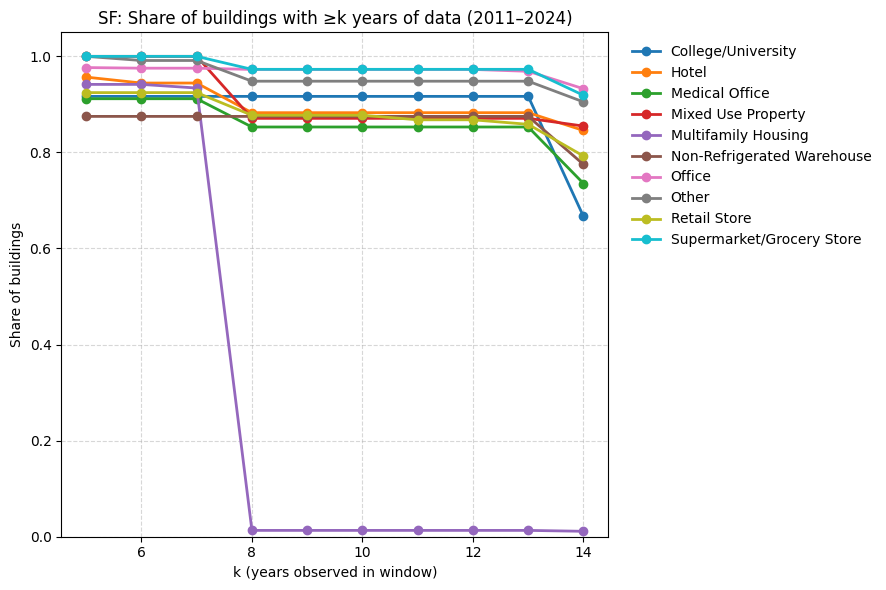

In [110]:
start_year, end_year = 2011, 2024
min_window = 5

sf_window_df = sf_chi.copy()
sf_window_df = sf_window_df[
    (sf_window_df["Data Year"] >= start_year) & (sf_window_df["Data Year"] <= end_year)
]
sf_window_df = sf_window_df.dropna(
    subset=["Address", "Primary Property Type", "Data Year"]
)

years_per_building = (
    sf_window_df.groupby(["Primary Property Type", "Address"])["Data Year"]
    .nunique()
    .reset_index(name="n_years")
)

top_types = years_per_building["Primary Property Type"].value_counts().head(10).index
years_per_building = years_per_building[
    years_per_building["Primary Property Type"].isin(top_types)
]

window_len = end_year - start_year + 1
ks = np.arange(min_window, window_len + 1)

rows: list[dict[str, object]] = []
for ptype, group_df in years_per_building.groupby("Primary Property Type"):
    for k in ks:
        rows.append(
            {
                "Primary Property Type": ptype,
                "k_years": int(k),
                "share_ge_k": float((group_df["n_years"] >= k).mean()),
            }
        )

survival_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 6))
for ptype, group_df in survival_df.groupby("Primary Property Type"):
    group_df = group_df.sort_values("k_years")
    ax.plot(
        group_df["k_years"],
        group_df["share_ge_k"],
        marker="o",
        linewidth=2,
        label=ptype,
    )

ax.set_title(f"SF: Share of buildings with ≥k years of data ({start_year}–{end_year})")
ax.set_xlabel("k (years observed in window)")
ax.set_ylabel("Share of buildings")
ax.set_ylim(0, 1.05)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
fig.tight_layout()
plt.show()

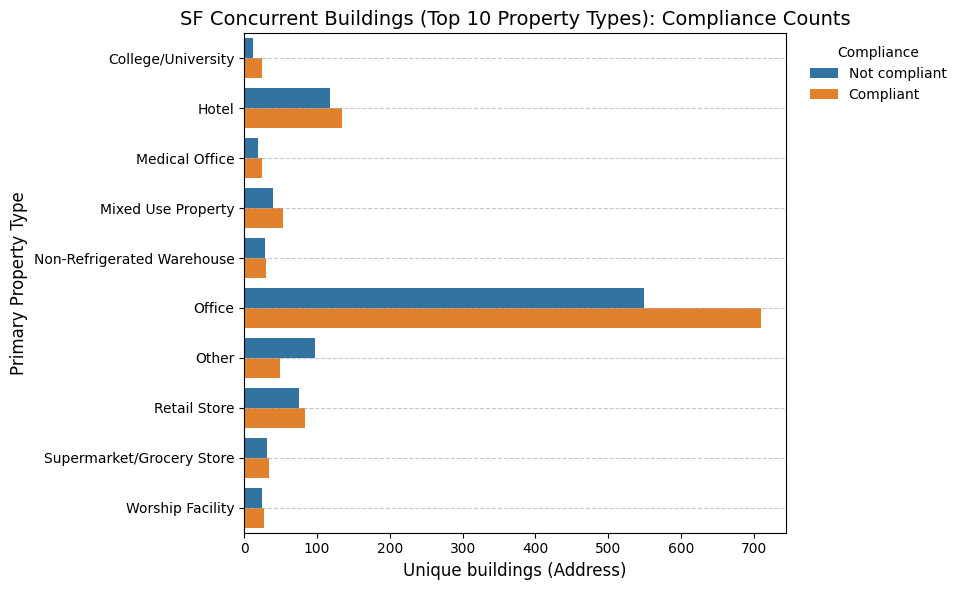

In [89]:
sf = sf_concurrent.copy()
sf["is_compliant"] = sf["Reporting Status"].str.contains(
    "complied", case=False, na=False
)

sf_top10 = (
    sf.groupby("Primary Property Type")["Address"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .index
)

sf_counts = (
    sf[sf["Primary Property Type"].isin(sf_top10)]
    .groupby(["Primary Property Type", "is_compliant"])["Address"]
    .nunique()
    .reset_index(name="buildings")
)

sf_counts["Compliance"] = sf_counts["is_compliant"].map(
    {True: "Compliant", False: "Not compliant"}
)

fig, ax = pu.plot_bar(
    data=sf_counts,
    x="buildings",
    y="Primary Property Type",
    hue="Compliance",
    title="SF Concurrent Buildings (Top 10 Property Types): Compliance Counts",
    xlabel="Unique buildings (Address)",
    ylabel="Primary Property Type",
    figsize=(10, 6),
    rotate_xticks=0,
)

ax.legend(
    title="Compliance",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)

Multifamily housing was a key component in SF raw dataset, but they normally have around 8.6 yrs (not concurrent).

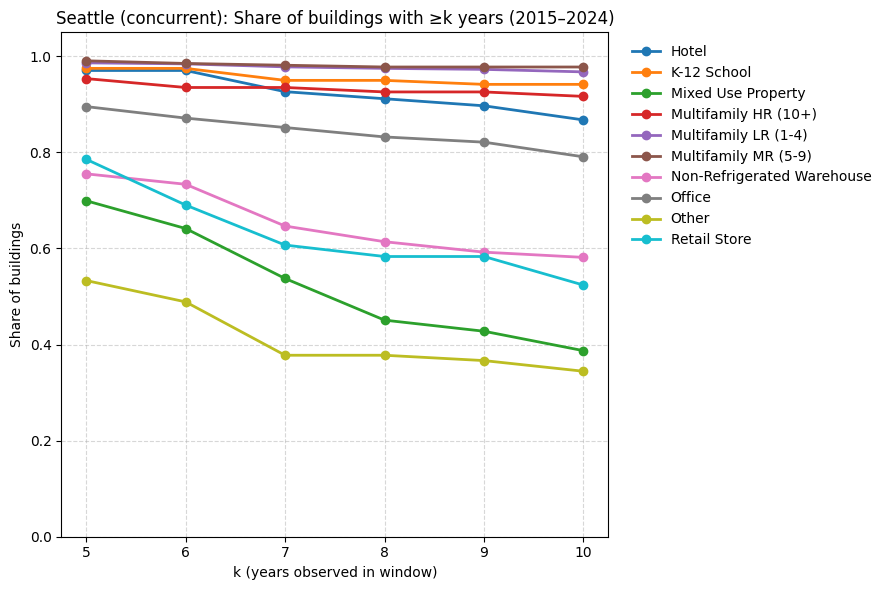

In [108]:
start_year, end_year = 2015, 2024
min_window = 5

sea_window_df = sea_concurrent.copy()
sea_window_df = sea_window_df[
    (sea_window_df["Data Year"] >= start_year)
    & (sea_window_df["Data Year"] <= end_year)
]
sea_window_df = sea_window_df.dropna(
    subset=["Address", "Primary Property Type", "Data Year"]
)

years_per_building = (
    sea_window_df.groupby(["Primary Property Type", "Address"])["Data Year"]
    .nunique()
    .reset_index(name="n_years")
)

top_types = years_per_building["Primary Property Type"].value_counts().head(10).index
years_per_building = years_per_building[
    years_per_building["Primary Property Type"].isin(top_types)
]

window_len = end_year - start_year + 1
ks = np.arange(min_window, window_len + 1)

rows: list[dict[str, object]] = []
for ptype, group_df in years_per_building.groupby("Primary Property Type"):
    for k in ks:
        rows.append(
            {
                "Primary Property Type": ptype,
                "k_years": int(k),
                "share_ge_k": float((group_df["n_years"] >= k).mean()),
            }
        )

survival_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 6))
for ptype, group_df in survival_df.groupby("Primary Property Type"):
    group_df = group_df.sort_values("k_years")
    ax.plot(
        group_df["k_years"],
        group_df["share_ge_k"],
        marker="o",
        linewidth=2,
        label=ptype,
    )

ax.set_title(
    f"Seattle (concurrent): Share of buildings with ≥k years ({start_year}–{end_year})"
)
ax.set_xlabel("k (years observed in window)")
ax.set_ylabel("Share of buildings")
ax.set_ylim(0, 1.05)
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
fig.tight_layout()
plt.show()

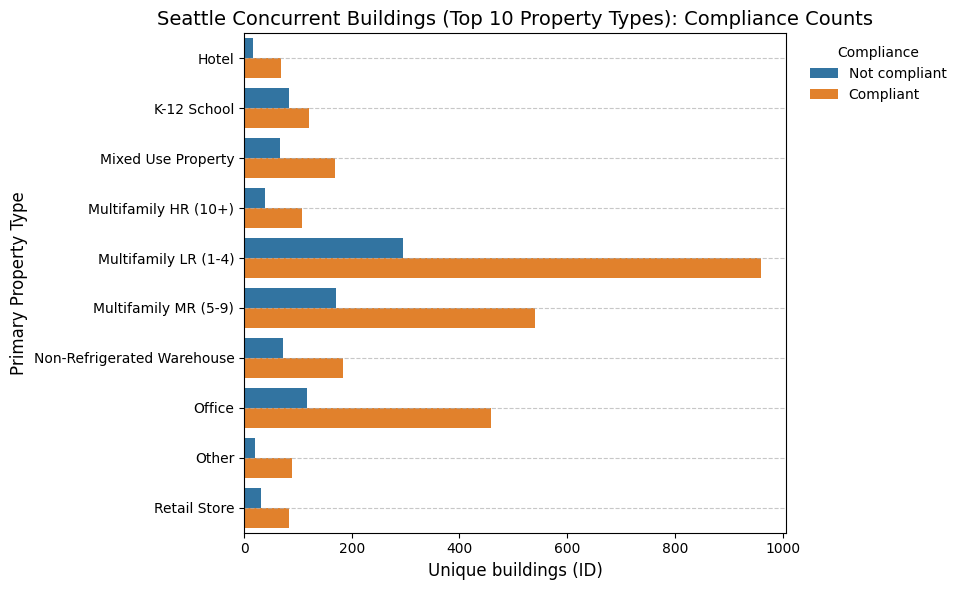

In [106]:
sea = sea_concurrent.copy()
sea["is_compliant"] = sea["Reporting Status"].str.lower().eq("compliant")

sea_top10 = (
    sea.groupby("Primary Property Type")["ID"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .index
)

sea_counts = (
    sea[sea["Primary Property Type"].isin(sea_top10)]
    .groupby(["Primary Property Type", "is_compliant"])["ID"]
    .nunique()
    .reset_index(name="buildings")
)

sea_counts["Compliance"] = sea_counts["is_compliant"].map(
    {True: "Compliant", False: "Not compliant"}
)

fig, ax = pu.plot_bar(
    data=sea_counts,
    x="buildings",
    y="Primary Property Type",
    hue="Compliance",
    title="Seattle Concurrent Buildings (Top 10 Property Types): Compliance Counts",
    xlabel="Unique buildings (ID)",
    ylabel="Primary Property Type",
    figsize=(10, 6),
    rotate_xticks=0,
)

ax.legend(
    title="Compliance",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
)